<a href="https://colab.research.google.com/github/SeloJumadiko/-data-science-2026/blob/main/Pertemuan5_%5BSelo_Jumadiko%5D_%5B240401010276%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Nama Lengkap : Selo Jumadiko
###NIM : 240401010276
###Kelas : IF403

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
penguins = sns.load_dataset('penguins')

# Membersihkan data dari nilai non-numerik/kosong pada kolom utama demi keakuratan visualisasi
main_cols = ['species', 'island', 'bill_length_mm', 'flipper_length_mm']
penguins_clean = penguins[main_cols].dropna()

# Mengatur tema visual
sns.set_theme(style="whitegrid")

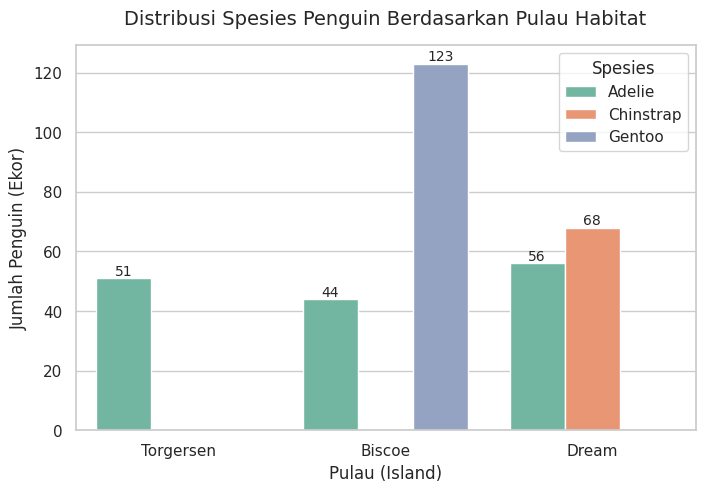

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=penguins_clean, x='island', hue='species', palette='Set2')
plt.title('Distribusi Spesies Penguin Berdasarkan Pulau Habitat', fontsize=14, pad=15)
plt.xlabel('Pulau (Island)')
plt.ylabel('Jumlah Penguin (Ekor)')
plt.legend(title='Spesies')

# Menambahkan angka di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.show()



*   What? Grafik menunjukkan bahwa Pulau
Biscoe didominasi oleh 119 ekor Gentoo dan 44 ekor Adelie, Pulau Dream dihuni oleh 68 ekor Chinstrap dan 55 ekor Adelie, sementara Pulau Torgersen hanya memiliki 47 ekor Adelie tanpa spesies lain.

*   So what? Informasi ini menunjukkan preferensi habitat, Gentoo dan Chinstrap tidak pernah berbagi wilayah di pulau yang sama, sedangkan Adelie bersifat universal karena mampu beradaptasi di ketiga pulau tersebut.

*   Now what? Langkah eksplorasi berikutnya adalah menganalisis apakah karakteristik fisik (seperti panjang paruh atau sirip) dari spesies Adelie mengalami perubahan morfologi atau perbedaan ukuran yang signifikan akibat perbedaan kondisi lingkungan di ketiga pulau tersebut.



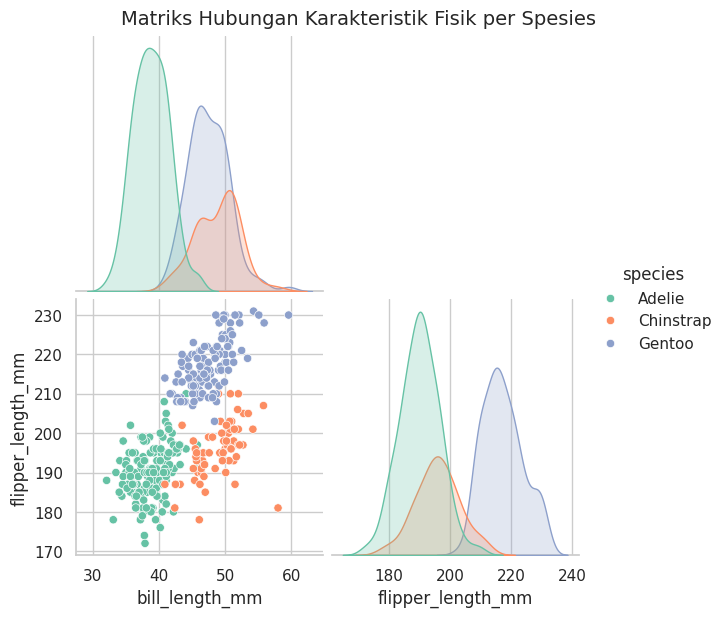

In [ ]:
# Membuat matriks pair plot untuk fitur numerik utama
pair_plot = sns.pairplot(penguins_clean[['species', 'bill_length_mm', 'flipper_length_mm']],
                         hue='species', palette='Set2', corner=True, height=3)
pair_plot.fig.suptitle('Matriks Hubungan Karakteristik Fisik per Spesies', y=1.02, fontsize=14)
plt.show()

*   What? Matriks plot ini memperlihatkan pengelompokan panjang paruh dan panjang sirip.

*   So what? Karakteristik penguin spesies adelie memiliki paruh dan sirip terpendek sedangkan penguin spesies Gentoo memiliki parus dan sirip terpanjang

*   Now what? ada korelasi mengenaipanjang paruh dan  panjang sirip





/tmp/ipykernel_1486/4086512127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins_clean, x='species', y='flipper_length_mm', palette='Set2', inner='quartile')


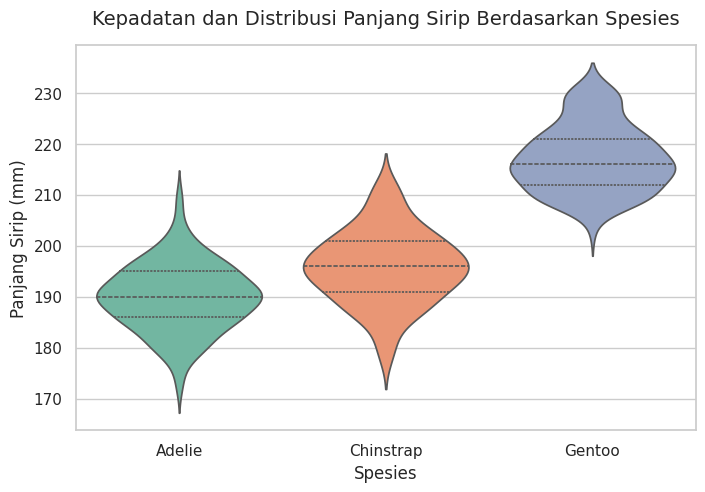

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=penguins_clean, x='species', y='flipper_length_mm', palette='Set2', inner='quartile')
plt.title('Kepadatan dan Distribusi Panjang Sirip Berdasarkan Spesies', fontsize=14, pad=15)
plt.xlabel('Spesies')
plt.ylabel('Panjang Sirip (mm)')
plt.show()

* What? Violin plot ini menunjukkan bahwa Gentoo memiliki sirip terpanjang dengan median mencapai sekitar 216 mm, jauh mengungguli Chinstrap yang memiliki median sekitar 196 mm, dan Adelie sebagai pemilik sirip terpendek dengan median mendekati 190 mm.  
* So what? Bentuk sebaran Gentoo yang memanjang menunjukkan variabilitas ukuran sirip yang lebih lebar di dalam populasinya, berbeda dengan Adelie yang bentuknya lebih menggembung padat di tengah, menandakan ukuran siripnya jauh lebih seragam.
* Now what? Kita perlu menyelidiki lebih lanjut apakah rentang variasi yang lebar pada panjang sirip Gentoo (dari 200 mm hingga lebih dari 230 mm) didorong oleh faktor jenis kelamin (sexual dimorphism) antara penguin jantan dan betina.






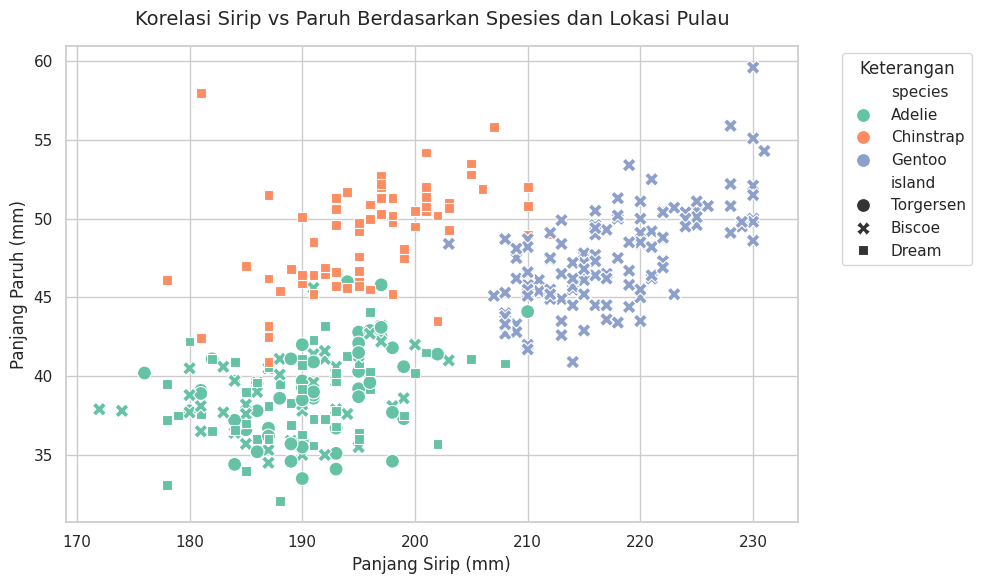

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins_clean, x='flipper_length_mm', y='bill_length_mm',
                hue='species', style='island', s=100, palette='Set2')
plt.title('Korelasi Sirip vs Paruh Berdasarkan Spesies dan Lokasi Pulau', fontsize=14, pad=15)
plt.xlabel('Panjang Sirip (mm)')
plt.ylabel('Panjang Paruh (mm)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Keterangan')
plt.tight_layout()
plt.show()

* What? Scatter plot mengonfirmasi adanya korelasi positif (makin panjang sirip, makin panjang paruh) sekaligus menunjukkan bahwa klaster Gentoo (sirip > 210 mm) hanya bersimbol bulat (Pulau Biscoe) dan klaster Chinstrap (paruh > 45 mm, sirip < 210 mm) hanya bersimbol silang (Pulau Dream).
* So what? Plot gabungan ini mengunci kesimpulan bahwa dimensi fisik penguin terikat erat dengan ekosistem pulau tempat mereka tinggal, membuat kombinasi dimensi tubuh dan data lokasi menjadi identitas unik bagi tiap kelompok.
* Now what? Pertanyaan ekologi yang menarik untuk dikejar adalah apakah kesamaan ukuran paruh yang panjang antara Gentoo di Biscoe dan Chinstrap di Dream (keduanya berada di kisaran 45–55 mm) dipicu oleh jenis mangsa atau kesamaan rantai makanan di kedua pulau tersebut.



